In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", None)

model_data = pd.read_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\model_sample_cpi_wpi.csv",
    parse_dates=["date"]
)

model_data = (
    model_data
    .sort_values("date")
    .reset_index(drop=True)
)

display(model_data.head())

,date,cpi_combined,cpi_yoy,wpi_all,wpi_primary,wpi_fuel,wpi_manufacturing,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy,output_ppi,output_ppi_yoy
0,2024-04-01,186.7,4.828748,99.9,108.8,92.0,98.5,0.909091,6.666667,-2.127660,-0.605449,99.7,0.605449
1,2024-05-01,187.7,4.801787,100.4,110.1,91.7,98.9,1.825558,7.624633,0.328228,0.000000,100.1,1.521298
2,2024-06-01,190.2,5.082873,100.7,111.8,89.9,99.1,2.441506,8.228461,-0.662983,0.916497,100.4,2.240326
3,2024-07-01,193.0,3.596350,101.0,113.1,91.2,98.8,1.917255,4.819277,0.662252,1.022495,100.8,1.715439
4,2024-08-01,193.0,3.651987,100.8,113.8,90.9,98.4,1.306533,5.370370,-0.980392,0.305810,100.7,1.307847


In [2]:
cpi = (
    model_data[
        ["date", "cpi_yoy"]
    ]
    .dropna()
    .copy()
)

cpi = cpi.set_index("date")

display(cpi.head())
display(cpi.tail())

,cpi_yoy
date,
2024-04-01,4.828748
2024-05-01,4.801787
2024-06-01,5.082873
2024-07-01,3.596350
2024-08-01,3.651987


,cpi_yoy
date,
2026-03-01,3.125000
2026-04-01,2.803738
2026-05-01,2.590674
2026-06-01,1.956746
2026-07-01,0.968893


In [3]:
print("Observations:", len(cpi))
print("Start:", cpi.index.min())
print("End:", cpi.index.max())

Observations: 28
Start: 2024-04-01 00:00:00
End: 2026-07-01 00:00:00


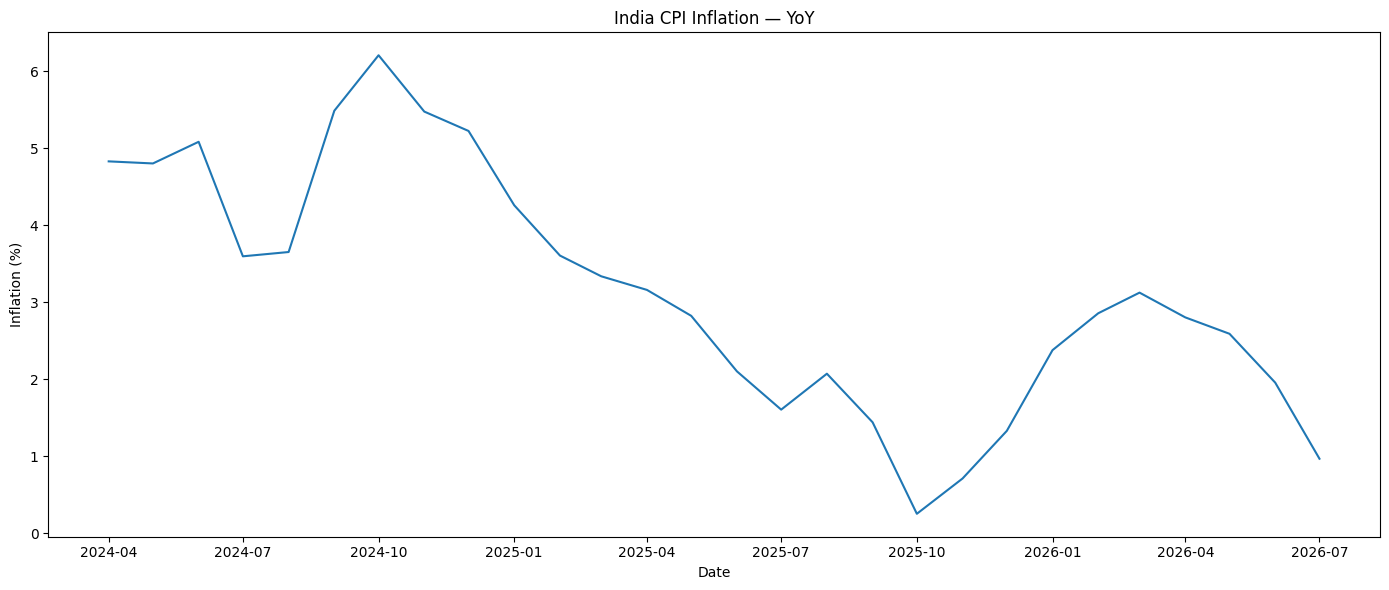

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    cpi.index,
    cpi["cpi_yoy"]
)

plt.title("India CPI Inflation — YoY")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.tight_layout()
plt.show()

In [5]:
adf_result = adfuller(
    cpi["cpi_yoy"],
    autolag="AIC"
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Used lags:", adf_result[2])
print("Number of observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.483598522499388
p-value: 0.5416087518544375
Used lags: 1
Number of observations: 26

Critical Values:
1%: -3.7112123008648155
5%: -2.981246804733728
10%: -2.6300945562130176


C:\Users\Adity\AppData\Local\Temp\ipykernel_18008\3361191535.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(


In [6]:
kpss_result = kpss(
    cpi["cpi_yoy"],
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Used lags:", kpss_result[2])

print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"{key}: {value}")

KPSS Statistic: 0.575049772393473
p-value: 0.024904566146047906
Used lags: 3

Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\Adity\AppData\Local\Temp\ipykernel_18008\401884115.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_result = kpss(


In [7]:
cpi_diff = cpi["cpi_yoy"].diff().dropna()

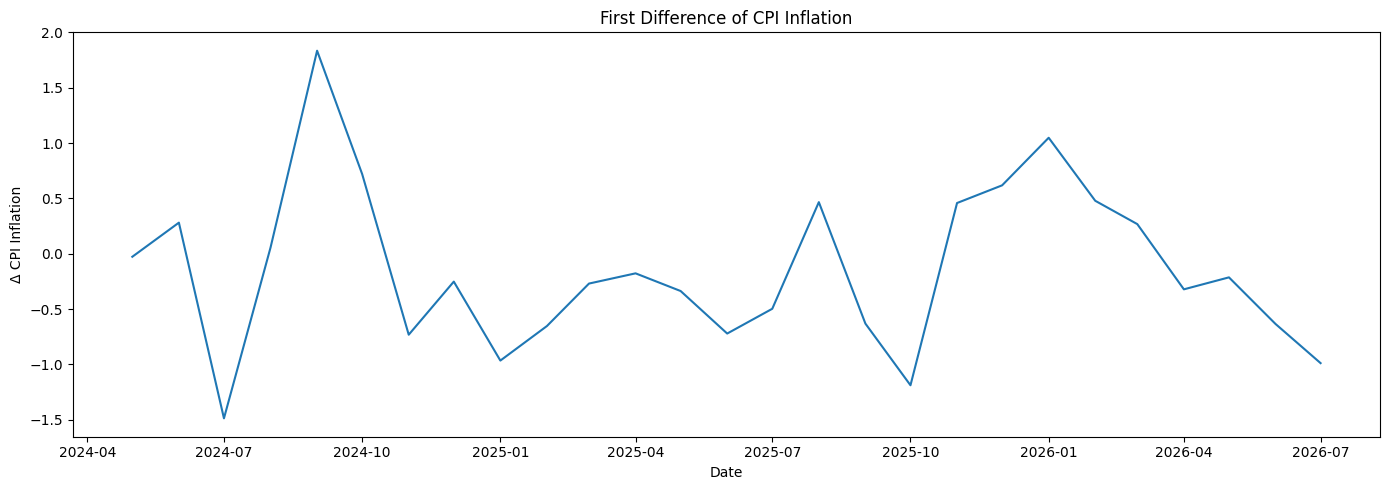

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    cpi_diff.index,
    cpi_diff
)

plt.title("First Difference of CPI Inflation")
plt.xlabel("Date")
plt.ylabel("Δ CPI Inflation")

plt.tight_layout()
plt.show()

In [9]:
adf_diff = adfuller(
    cpi_diff,
    autolag="AIC"
)

print("Differenced ADF p-value:", adf_diff[1])

Differenced ADF p-value: 0.007310135685954798


C:\Users\Adity\AppData\Local\Temp\ipykernel_18008\4270801709.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(


In [12]:
print("Total observations:", len(cpi))
print("Missing CPI YoY:", cpi["cpi_yoy"].isna().sum())
print("Usable observations:", cpi["cpi_yoy"].dropna().shape[0])

Total observations: 28
Missing CPI YoY: 0
Usable observations: 28


In [14]:
print("Type:", type(cpi["cpi_yoy"]))
print("Shape:", cpi["cpi_yoy"].shape)

cpi_acf = cpi["cpi_yoy"].dropna()

print("After dropna:")
print("Type:", type(cpi_acf))
print("Shape:", cpi_acf.shape)
print("NaNs:", cpi_acf.isna().sum())

Type: <class 'pandas.core.series.Series'>
Shape: (28,)
After dropna:
Type: <class 'pandas.core.series.Series'>
Shape: (28,)
NaNs: 0


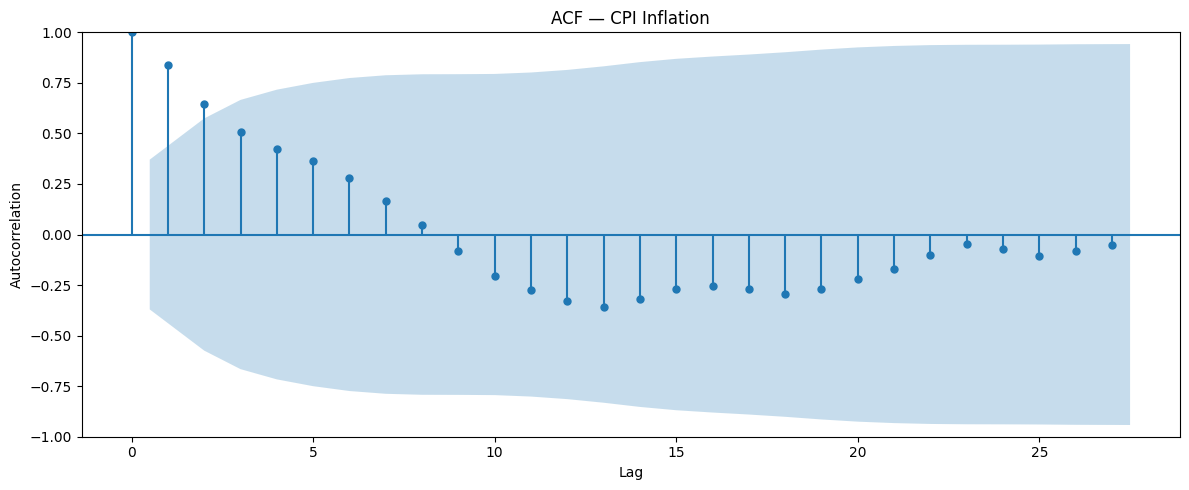

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

cpi_acf = pd.to_numeric(
    cpi["cpi_yoy"],
    errors="coerce"
).dropna()

cpi_acf = np.asarray(cpi_acf).ravel()

max_lags = min(36, len(cpi_acf) - 1)

plt.figure(figsize=(12, 5))

plot_acf(
    cpi_acf,
    lags=max_lags,
    ax=plt.gca()
)

plt.title("ACF — CPI Inflation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

In [16]:
cpi_acf = np.asarray(cpi_acf).ravel()

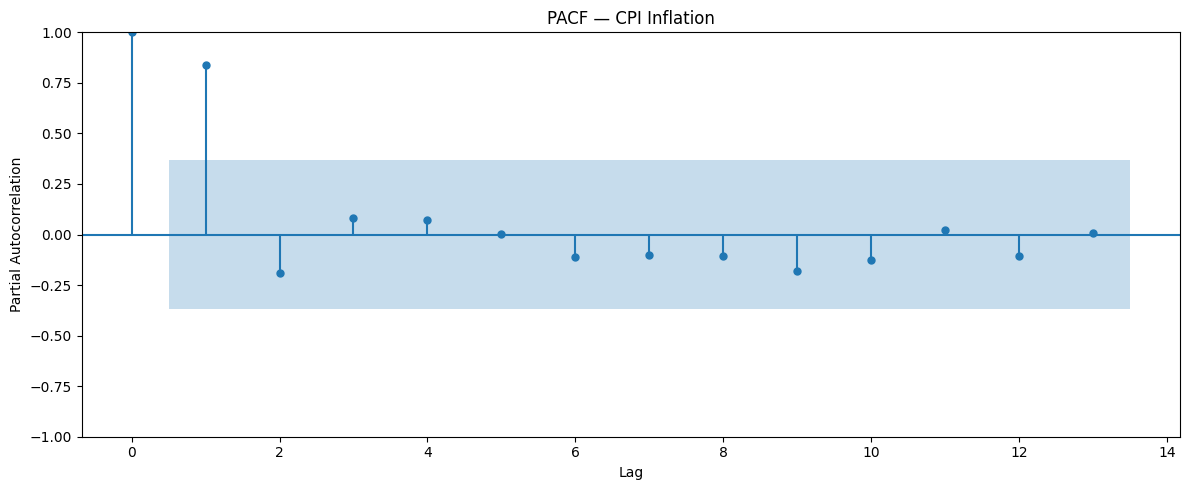

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Clean CPI inflation series
cpi_pacf = pd.to_numeric(
    cpi["cpi_yoy"],
    errors="coerce"
).dropna()

# Convert to a clean 1-D NumPy array
cpi_pacf = np.asarray(cpi_pacf).ravel()

# Use a safe number of lags
max_lags = min(36, len(cpi_pacf) // 2 - 1)

plt.figure(figsize=(12, 5))

plot_pacf(
    cpi_pacf,
    lags=max_lags,
    method="ywm",
    ax=plt.gca()
)

plt.title("PACF — CPI Inflation")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

In [19]:
print(type(cpi_pacf))
print(cpi_pacf.shape)
print(np.isnan(cpi_pacf).sum())

<class 'numpy.ndarray'>
(28,)
0


In [20]:
seasonal_lags = [6, 12, 18, 24, 36]

for lag in seasonal_lags:
    correlation = (
        cpi["cpi_yoy"]
        .autocorr(lag=lag)
    )

    print(
        f"Lag {lag}: {correlation:.4f}"
    )

Lag 6: 0.3803
Lag 12: -0.3076
Lag 18: 0.1615
Lag 24: 0.8046
Lag 36: nan


In [21]:
cpi["month"] = cpi.index.month

In [23]:
monthly_mean = (
    cpi
    .groupby("month")["cpi_yoy"]
    .mean()
)

display(monthly_mean)
monthly_std = (
    cpi
    .groupby("month")["cpi_yoy"]
    .std()
)

display(monthly_std)

month
1     3.318625
2     3.231585
3     3.230961
4     3.597545
5     3.405372
6     3.047556
7     2.057154
8     2.862263
9     3.463981
10    3.230109
11    3.093754
12    3.277041
Name: cpi_yoy, dtype: float64

month
1     1.329552
2     0.529542
3     0.149851
4     1.081042
5     1.214928
6     1.764153
7     1.370543
8     1.116839
9     2.859778
10    4.208761
11    3.367647
12    2.752678
Name: cpi_yoy, dtype: float64

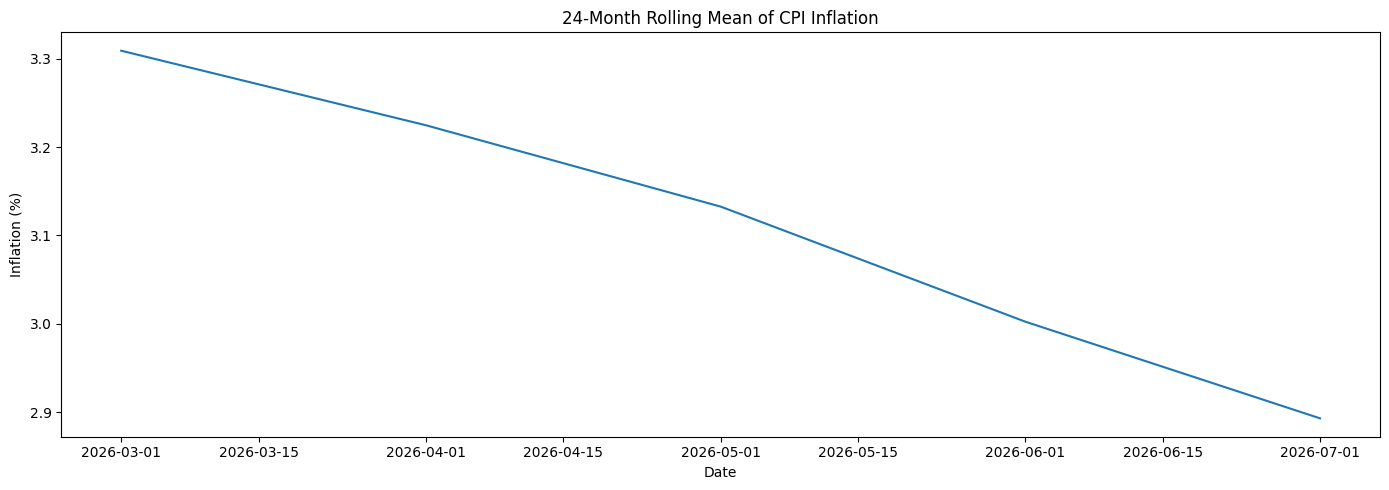

In [24]:
rolling_mean = (
    cpi["cpi_yoy"]
    .rolling(24)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    cpi.index,
    rolling_mean
)

plt.title("24-Month Rolling Mean of CPI Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.tight_layout()
plt.show()

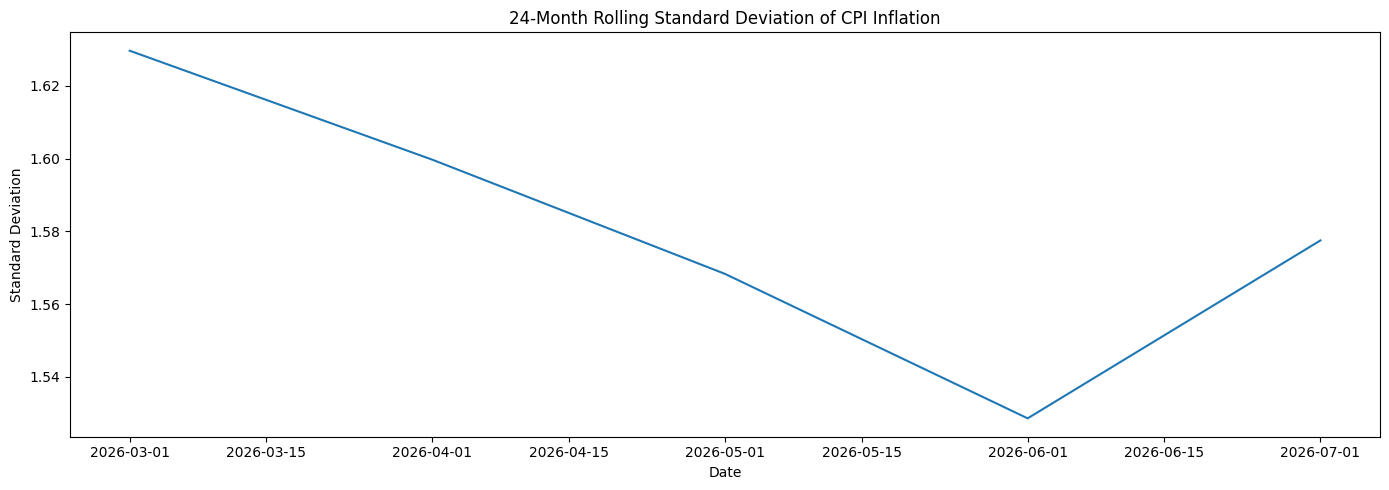

In [25]:
rolling_std = (
    cpi["cpi_yoy"]
    .rolling(24)
    .std()
)

plt.figure(figsize=(14, 5))

plt.plot(
    cpi.index,
    rolling_std
)

plt.title("24-Month Rolling Standard Deviation of CPI Inflation")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")

plt.tight_layout()
plt.show()

In [26]:
diagnostic_summary = pd.DataFrame({
    "Test": [
        "ADF — Level",
        "KPSS — Level",
        "ADF — First Difference"
    ],
    "Statistic": [
        adf_result[0],
        kpss_result[0],
        adf_diff[0]
    ],
    "p_value": [
        adf_result[1],
        kpss_result[1],
        adf_diff[1]
    ]
})

display(diagnostic_summary)

,Test,Statistic,p_value
0,ADF — Level,-1.483599,0.541609
1,KPSS — Level,0.575050,0.024905
2,ADF — First Difference,-3.527422,0.007310


In [27]:
diagnostic_summary = pd.DataFrame({
    "Test": [
        "ADF — CPI Inflation Level",
        "KPSS — CPI Inflation Level",
        "ADF — First Difference"
    ],
    "Statistic": [
        adf_result[0],
        kpss_result[0],
        adf_diff[0]
    ],
    "p_value": [
        adf_result[1],
        kpss_result[1],
        adf_diff[1]
    ]
})

display(diagnostic_summary)

,Test,Statistic,p_value
0,ADF — CPI Inflation Level,-1.483599,0.541609
1,KPSS — CPI Inflation Level,0.575050,0.024905
2,ADF — First Difference,-3.527422,0.007310


In [28]:
diagnostic_summary["Statistic"] = diagnostic_summary["Statistic"].round(4)
diagnostic_summary["p_value"] = diagnostic_summary["p_value"].round(4)

display(diagnostic_summary)

,Test,Statistic,p_value
0,ADF — CPI Inflation Level,-1.4836,0.5416
1,KPSS — CPI Inflation Level,0.5750,0.0249
2,ADF — First Difference,-3.5274,0.0073


In [29]:
def interpret_adf(p_value, alpha=0.05):
    if p_value < alpha:
        return "Reject unit-root null → evidence of stationarity"
    return "Fail to reject unit-root null → insufficient evidence of stationarity"


def interpret_kpss(p_value, alpha=0.05):
    if p_value < alpha:
        return "Reject stationarity null → evidence of non-stationarity"
    return "Fail to reject stationarity null → evidence consistent with stationarity"


print("ADF:", interpret_adf(adf_result[1]))
print("KPSS:", interpret_kpss(kpss_result[1]))
print("ADF First Difference:", interpret_adf(adf_diff[1]))

ADF: Fail to reject unit-root null → insufficient evidence of stationarity
KPSS: Reject stationarity null → evidence of non-stationarity
ADF First Difference: Reject unit-root null → evidence of stationarity


In [34]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf

# Clean CPI inflation series
cpi_acf_series = pd.to_numeric(
    cpi["cpi_yoy"],
    errors="coerce"
).dropna()

# Check available observations
n_obs = len(cpi_acf_series)

print("Usable CPI inflation observations:", n_obs)

# Maximum lag we can safely request
max_acf_lag = min(36, n_obs - 1)

print("Maximum available ACF lag:", max_acf_lag)

# Calculate ACF
acf_values_all = acf(
    cpi_acf_series,
    nlags=max_acf_lag,
    fft=False
)

# Only request lags that actually exist
important_lags = [
    lag
    for lag in [1, 2, 3, 6, 12, 24, 36]
    if lag <= max_acf_lag
]

acf_summary = pd.DataFrame({
    "Lag": important_lags,
    "Autocorrelation": [
        acf_values_all[lag]
        for lag in important_lags
    ]
})

display(acf_summary)

Usable CPI inflation observations: 28
Maximum available ACF lag: 27


,Lag,Autocorrelation
0,1,0.837367
1,2,0.643591
2,3,0.504847
3,6,0.279419
4,12,-0.326585
5,24,-0.069700


In [35]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import pacf

# Clean CPI inflation series
cpi_pacf_series = pd.to_numeric(
    cpi["cpi_yoy"],
    errors="coerce"
).dropna()

# Safe maximum lag
max_pacf_lag = min(
    36,
    len(cpi_pacf_series) // 2 - 1
)

print("Usable observations:", len(cpi_pacf_series))
print("Maximum PACF lag:", max_pacf_lag)

pacf_values = pacf(
    cpi_pacf_series,
    nlags=max_pacf_lag,
    method="ywm"
)

pacf_summary = pd.DataFrame({
    "Lag": range(len(pacf_values)),
    "Partial_Autocorrelation": pacf_values
})

important_lags_pacf = [
    lag for lag in [1, 2, 3, 6, 12, 24, 36]
    if lag <= max_pacf_lag
]

display(
    pacf_summary[
        pacf_summary["Lag"].isin(important_lags_pacf)
    ]
)

Usable observations: 28
Maximum PACF lag: 13


,Lag,Partial_Autocorrelation
1,1,0.837367
2,2,-0.192733
3,3,0.081487
6,6,-0.111879
12,12,-0.107040


In [36]:
print("ACF summary:")
display(acf_summary)

print("\nPACF summary:")
display(
    pacf_summary[
        pacf_summary["Lag"].isin(important_lags_pacf)
    ]
)

ACF summary:


,Lag,Autocorrelation
0,1,0.837367
1,2,0.643591
2,3,0.504847
3,6,0.279419
4,12,-0.326585
5,24,-0.069700



PACF summary:


,Lag,Partial_Autocorrelation
1,1,0.837367
2,2,-0.192733
3,3,0.081487
6,6,-0.111879
12,12,-0.107040


In [37]:
diagnostic_summary.to_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\diagnostic_summary.csv",
    index=False
)

acf_summary.to_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\acf_summary.csv",
    index=False
)

pacf_summary.to_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\pacf_summary.csv",
    index=False
)

In [38]:
display(diagnostic_summary)
display(acf_summary)
display(
    pacf_summary[
        pacf_summary["Lag"].isin([1,2,3,6,12,24,36])
    ]
)

,Test,Statistic,p_value
0,ADF — CPI Inflation Level,-1.4836,0.5416
1,KPSS — CPI Inflation Level,0.5750,0.0249
2,ADF — First Difference,-3.5274,0.0073


,Lag,Autocorrelation
0,1,0.837367
1,2,0.643591
2,3,0.504847
3,6,0.279419
4,12,-0.326585
5,24,-0.069700


,Lag,Partial_Autocorrelation
1,1,0.837367
2,2,-0.192733
3,3,0.081487
6,6,-0.111879
12,12,-0.107040


## Econometric Diagnostic Summary

### Stationarity

The Augmented Dickey-Fuller (ADF) and KPSS tests were applied to CPI inflation in levels. The two tests have complementary null hypotheses and are interpreted jointly.

### Autocorrelation

The ACF and PACF were examined up to 36 lags to identify serial dependence and possible seasonal behavior.

### Seasonality

Because CPI inflation is observed monthly, particular attention was given to lag 12 and other seasonal lags.

### Modelling implication

The stationarity tests, ACF, PACF and seasonal diagnostics are used to define candidate ARIMA and SARIMA specifications. Final model selection will be based on residual diagnostics and rolling out-of-sample forecasting performance rather than in-sample fit alone.

In [39]:
cpi_diff = cpi["cpi_yoy"].diff().dropna()

Type: <class 'pandas.core.series.Series'>
Observations: 27
Missing values: 0


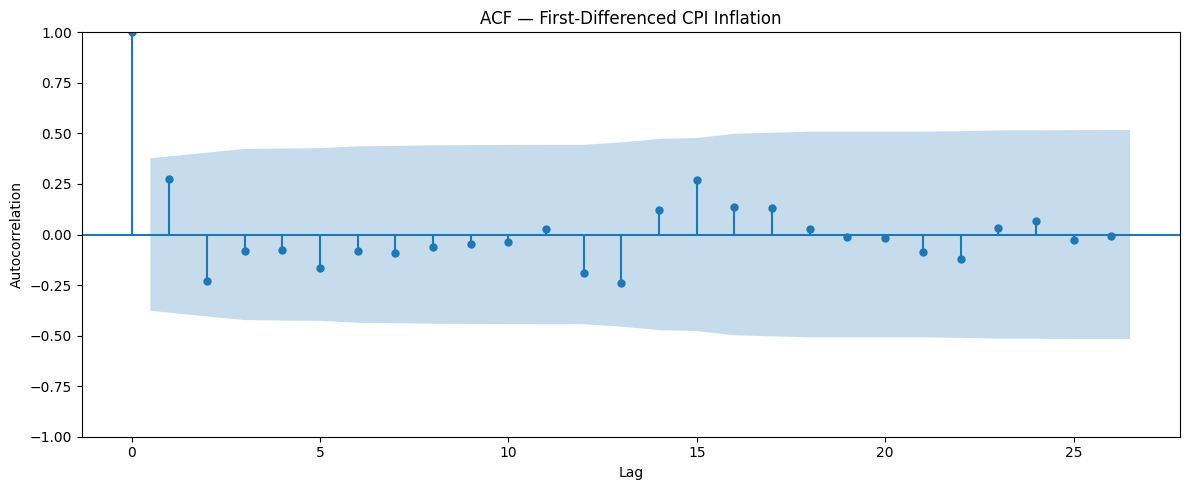

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Create first difference of CPI inflation
cpi_diff = pd.to_numeric(
    cpi["cpi_yoy"],
    errors="coerce"
).diff().dropna()

# Force a clean 1-dimensional numeric array
cpi_diff = pd.Series(cpi_diff).dropna()

print("Type:", type(cpi_diff))
print("Observations:", len(cpi_diff))
print("Missing values:", cpi_diff.isna().sum())

# Safe number of lags
max_lags = min(36, len(cpi_diff) - 1)

plt.figure(figsize=(12, 5))

plot_acf(
    cpi_diff.to_numpy(),
    lags=max_lags,
    ax=plt.gca()
)

plt.title("ACF — First-Differenced CPI Inflation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [42]:
print(type(cpi_diff))
print(cpi_diff.shape)

<class 'pandas.core.series.Series'>
(27,)


Observations: 27
Dimensions: 1
Missing values: 0
PACF lags: 12


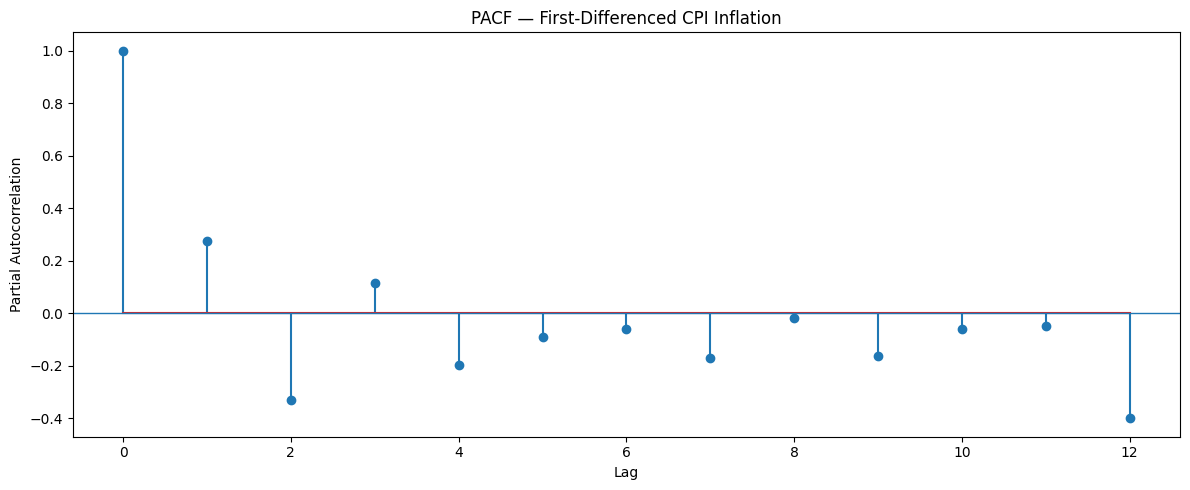

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

# Rebuild the first-differenced CPI inflation series from the source
cpi_pacf_series = pd.to_numeric(
    cpi["cpi_yoy"],
    errors="coerce"
).dropna()

cpi_pacf_series = cpi_pacf_series.diff().dropna()

# Convert to a clean 1-D NumPy array
pacf_input = cpi_pacf_series.to_numpy(dtype=float).ravel()

# Check input
print("Observations:", len(pacf_input))
print("Dimensions:", pacf_input.ndim)
print("Missing values:", np.isnan(pacf_input).sum())

# Safe maximum number of lags
max_lags = min(36, len(pacf_input) // 2 - 1)

print("PACF lags:", max_lags)

# Calculate PACF numerically
pacf_values = pacf(
    pacf_input,
    nlags=max_lags,
    method="ywm"
)

# Plot
plt.figure(figsize=(12, 5))

plt.stem(
    range(len(pacf_values)),
    pacf_values
)

plt.axhline(0, linewidth=1)

plt.title("PACF — First-Differenced CPI Inflation")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

In [47]:
adf_diff = adfuller(
    cpi_diff,
    autolag="AIC"
)

print("ADF statistic:", adf_diff[0])
print("ADF p-value:", adf_diff[1])

ADF statistic: -3.527422308913769
ADF p-value: 0.007310135685954798


C:\Users\Adity\AppData\Local\Temp\ipykernel_18008\2135576934.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(


## Diagnostic Results — Preliminary Findings

### Stationarity

ADF test on CPI inflation:
p-value = 0.5416

KPSS test on CPI inflation:
p-value = 0.0249

ADF test on first-differenced CPI inflation:
p-value = 0.0073

### Preliminary interpretation

The level CPI inflation series does not exhibit strong evidence of
stationarity under the ADF/KPSS results, while the first-differenced
series is stationary according to the ADF test.

The first-difference therefore provides the initial basis for
considering d = 1 in the ARIMA specification.

### Autocorrelation

The level CPI inflation series exhibits strong positive
autocorrelation at short lags, particularly lag 1.

The PACF shows a dominant lag-1 relationship.

Lag 12 also deserves investigation because the data are monthly and
the ACF indicates possible annual seasonal structure.

### Modelling implication

Candidate ARIMA/SARIMA specifications will be selected using these
diagnostics and subsequently validated using residual diagnostics and
rolling out-of-sample forecasting performance.